In [2]:
import sys

!{sys.executable} -m pip install python-dotenv

In [2]:
import sys

!{sys.executable} -m pip install pymongo dnspython

  Using cached dnspython-2.8.0-py3-none-any.whl.metadata (5.7 kB)
   ---------------------------------------- 0.0/815.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/815.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/815.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/815.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/815.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/815.7 kB ? eta -:--:--
   ------------ --------------------------- 262.1/815.7 kB ? eta -:--:--
   ------------ --------------------------- 262.1/815.7 kB ? eta -:--:--
   ------------ --------------------------- 262.1/815.7 kB ? eta -:--:--
   ------------ --------------------------- 262.1/815.7 kB ? eta -:--:--
   ------------ --------------------------- 262.1/815.7 kB ? eta -:--:--
   ------------ --------------------------- 262.1/815.7 kB ? eta -:--:--
   ------------ --------------------------- 262.1/815.7 kB ? eta -:--:

In [41]:
import os
from dotenv import load_dotenv
from pymongo import MongoClient

load_dotenv()

MONGO_URI = os.getenv("MONGO_URI")


client = MongoClient(MONGO_URI)

db = client["aqi_pipeline"]

collection = db["weather_features"]

In [42]:
db

Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'aqi_pipeline')

In [43]:
collection

Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'aqi_pipeline'), 'weather_features')

In [44]:
import os
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from datetime import datetime
 

In [45]:
!pip install pandas

In [46]:
%pip install matplotlib, seaborn, pymongo, dnspython


Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: 'matplotlib,': Expected end or semicolon (after name and no valid version specifier)
    matplotlib,
              ^


In [47]:
%pip install matplotlib 

In [48]:
import os
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from datetime import datetime
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger(__name__)
 
MONGODB_URL = os.getenv("MONGO_URL", "")
REPORT_DIR  = Path("data/eda_reports")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

In [49]:
# ── Color Palette ──────────────────────────────────────────────────────────
COLORS = {
    "primary":   "#E63946",
    "secondary": "#457B9D",
    "accent":    "#F4A261",
    "good":      "#2DC653",
    "moderate":  "#FFD700",
    "unhealthy": "#FF6B35",
    "very":      "#C1121F",
    "hazardous": "#6D2B2B",
    "bg":        "#1A1A2E",
    "panel":     "#16213E",
    "text":      "#E0E0E0",
}
AQI_COLORS = ["#2DC653","#FFD700","#FF6B35","#E63946","#C1121F","#6D2B2B"]
 
plt.rcParams.update({
    "figure.facecolor":  COLORS["bg"],
    "axes.facecolor":    COLORS["panel"],
    "axes.edgecolor":    "#333355",
    "axes.labelcolor":   COLORS["text"],
    "xtick.color":       COLORS["text"],
    "ytick.color":       COLORS["text"],
    "text.color":        COLORS["text"],
    "grid.color":        "#333355",
    "grid.linestyle":    "--",
    "grid.alpha":        0.5,
    "font.family":       "monospace",
})

In [50]:
# ── Load Data ──────────────────────────────────────────────────────────────
def load_data() -> pd.DataFrame:
    """Load from MongoDB if available, else from CSV backups."""
    if MONGO_URL:
        try:
            from pymongo import MongoClient
            log.info("Loading data from MongoDB Atlas...")
            client = MongoClient(MONGO_URL)
            db     = client["aqi_pipeline"]
            col    = db["weather_aqi_features"]
            docs   = list(col.find({}, {"_id": 0}))
            client.close()
            df = pd.DataFrame(docs)
            log.info(f"Loaded {len(df)} rows from MongoDB")
            return df
        except Exception as e:
            log.warning(f"MongoDB load failed: {e} — falling back to CSV")
 

In [51]:
%pip install seaborn


Note: you may need to restart the kernel to use updated packages.


In [52]:
# Fallback: CSV backups
csv_dirs = [
    Path("data/historical_backup"),
    Path("data/features"),
    Path("data/features_store_backup"),
]

def load_csv_backups():
    dfs = []

    for d in csv_dirs:
        if not d.exists():
            continue

        for f in sorted(d.glob("*.csv")):
            try:
                dfs.append(pd.read_csv(f, on_bad_lines="skip", engine="python"))
            except Exception as e:
                log.warning(f"Skipping {f}: {e}")

    if dfs:
        df = pd.concat(dfs, ignore_index=True)

        if "timestamp" in df.columns:
            df = df.drop_duplicates(subset=["timestamp"])

        log.info(f"Loaded {len(df)} rows from CSV backups")
        return df

    raise RuntimeError("No data found. Run generate_historical_data.py first.")


def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
        df = df.sort_values("timestamp").reset_index(drop=True)

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

    return df

In [53]:
from pathlib import Path

In [54]:
# ── Plot 1: AQI Trend Over Time ────────────────────────────────────────────
def plot_aqi_trend(df: pd.DataFrame):
    fig, axes = plt.subplots(2, 1, figsize=(16, 8))
    fig.suptitle("AQI Trend Over Time — Lahore", fontsize=16,
                 color=COLORS["primary"], fontweight="bold", y=1.01)
 

In [56]:
df = load_csv_backups()
print(df.shape)
print(df.head())

2026-05-19 01:25:38,112 [INFO] Loaded 2393 rows from CSV backups


(2393, 68)
                   timestamp    city  hour  day_of_week  month  day_of_year  \
0  2026-02-09T00:00:00+00:00  Lahore   0.0          0.0    2.0         40.0   
1  2026-02-09T01:00:00+00:00  Lahore   1.0          0.0    2.0         40.0   
2  2026-02-09T02:00:00+00:00  Lahore   2.0          0.0    2.0         40.0   
3  2026-02-09T03:00:00+00:00  Lahore   3.0          0.0    2.0         40.0   
4  2026-02-09T04:00:00+00:00  Lahore   4.0          0.0    2.0         40.0   

   hour_sin  hour_cos  month_sin  month_cos  ...  aqi_change_rate_1h  \
0  0.000000  1.000000   0.866025        0.5  ...                 NaN   
1  0.258819  0.965926   0.866025        0.5  ...                 NaN   
2  0.500000  0.866025   0.866025        0.5  ...                 0.0   
3  0.707107  0.707107   0.866025        0.5  ...                 0.0   
4  0.866025  0.500000   0.866025        0.5  ...                 0.0   

   aqi_change_rate_6h  aqi_change_rate_24h  target_aqi_current  \
0              

In [69]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load CSV
df = pd.read_csv("data/historical_backup/historical_2026-02-09_2026-05-10.csv", 
                 on_bad_lines='skip', engine='python')

# Fix timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
df = df.dropna(subset=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)
print(df.shape)
print(df["timestamp"].head())

(2184, 68)
0   2026-02-09 00:00:00+00:00
1   2026-02-09 01:00:00+00:00
2   2026-02-09 02:00:00+00:00
3   2026-02-09 03:00:00+00:00
4   2026-02-09 04:00:00+00:00
Name: timestamp, dtype: datetime64[ns, UTC]


In [71]:
print(df.columns.tolist())
import matplotlib.pyplot as plt



['timestamp', 'city', 'hour', 'day_of_week', 'month', 'day_of_year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'is_weekend', 'is_peak_hour', 'is_night', 'season', 'temp_c', 'humidity_pct', 'windspeed_kmh', 'winddir_deg', 'windgusts_kmh', 'pressure_hpa', 'uv_index', 'dew_point_c', 'cloudcover_pct', 'visibility_m', 'precipitation_mm', 'rain_mm', 'heat_index_c', 'wind_chill_c', 'apparent_temp_delta', 'weathercode', 'aqi', 'dominant_poll', 'pm25_iaqi', 'pm10_iaqi', 'no2_iaqi', 'o3_iaqi', 'co_iaqi', 'so2_iaqi', 'aqi_cat_ordinal', 'aqi_cat_label', 'pollution_accumulation_idx', 'ventilation_idx', 'humidity_pm25_interaction', 'uv_o3_interaction', 'temp_range_c', 'temp_variance', 'wind_variance', 'aqi_lag_1h', 'aqi_lag_3h', 'aqi_lag_6h', 'aqi_lag_24h', 'aqi_rolling_3h_mean', 'aqi_rolling_3h_std', 'aqi_rolling_6h_mean', 'aqi_rolling_24h_mean', 'aqi_rolling_24h_max', 'aqi_change_rate_1h', 'aqi_change_rate_6h', 'aqi_change_rate_24h', 'target_aqi_current', 'target_aqi_

In [67]:
print(df.columns.tolist())

['city', 'hour', 'day_of_week', 'month', 'day_of_year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'is_weekend', 'is_peak_hour', 'is_night', 'season', 'temp_c', 'humidity_pct', 'windspeed_kmh', 'winddir_deg', 'windgusts_kmh', 'pressure_hpa', 'uv_index', 'dew_point_c', 'cloudcover_pct', 'visibility_m', 'precipitation_mm', 'rain_mm', 'heat_index_c', 'wind_chill_c', 'apparent_temp_delta', 'weathercode', 'aqi', 'dominant_poll', 'pm25_iaqi', 'pm10_iaqi', 'no2_iaqi', 'o3_iaqi', 'co_iaqi', 'so2_iaqi', 'aqi_cat_ordinal', 'aqi_cat_label', 'pollution_accumulation_idx', 'ventilation_idx', 'humidity_pm25_interaction', 'uv_o3_interaction', 'temp_range_c', 'temp_variance', 'wind_variance', 'aqi_lag_1h', 'aqi_lag_3h', 'aqi_lag_6h', 'aqi_lag_24h', 'aqi_rolling_3h_mean', 'aqi_rolling_3h_std', 'aqi_rolling_6h_mean', 'aqi_rolling_24h_mean', 'aqi_rolling_24h_max', 'aqi_change_rate_1h', 'aqi_change_rate_6h', 'aqi_change_rate_24h', 'target_aqi_current', 'target_aqi_cat_current',

In [75]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 4))
daily = df.set_index("timestamp")["aqi"].resample("D").mean()
ax.plot(daily.index, daily.values, color="#E63946", linewidth=1.5)
ax.set_title("Daily Mean AQI — Lahore")
ax.set_ylabel("AQI")
ax.grid(True)
plt.tight_layout()
plt.savefig("test_plot.png", dpi=120, bbox_inches="tight")
plt.show()
print("saved!")

saved!


In [76]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100


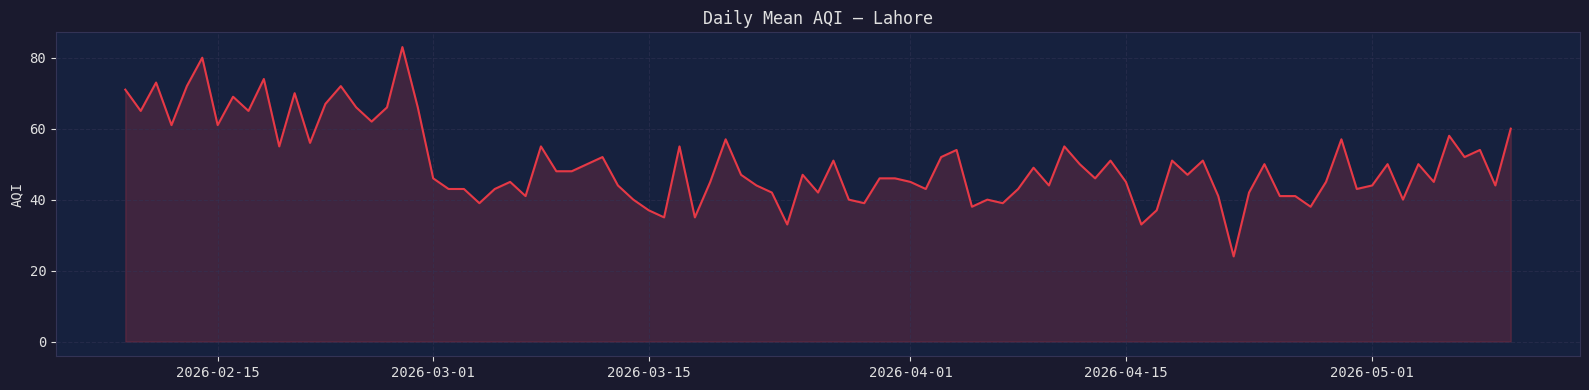

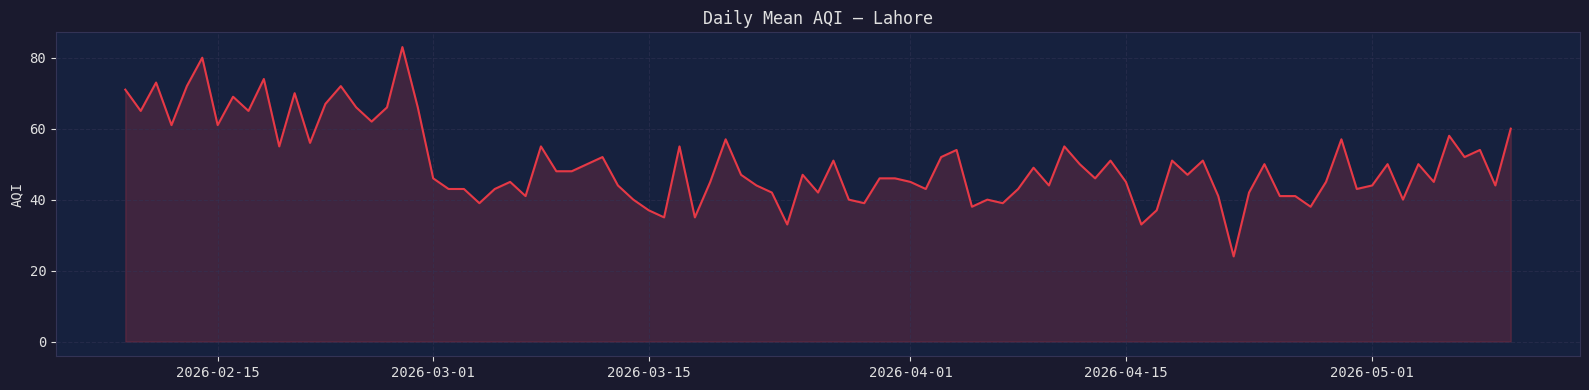

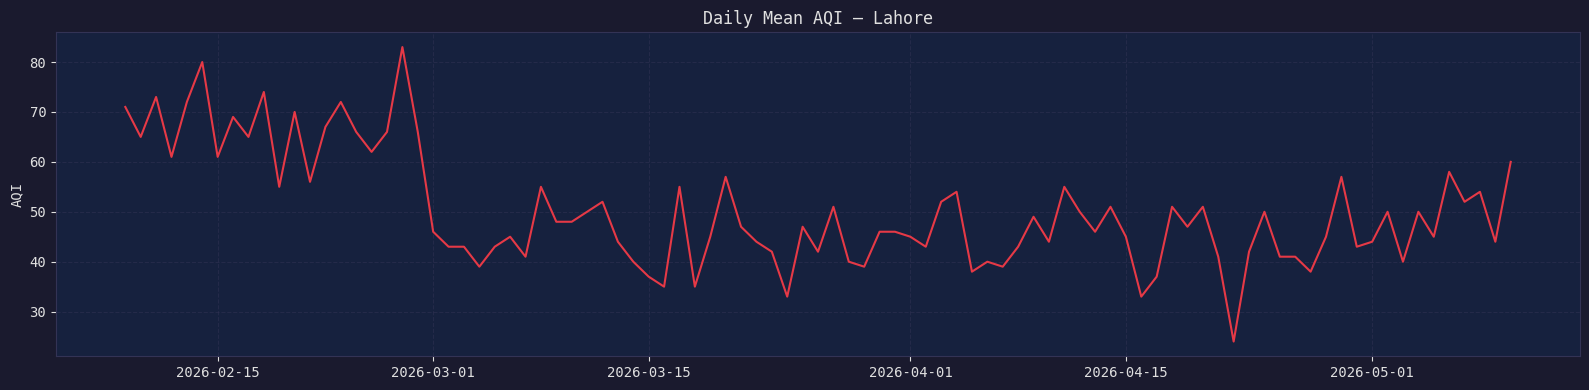

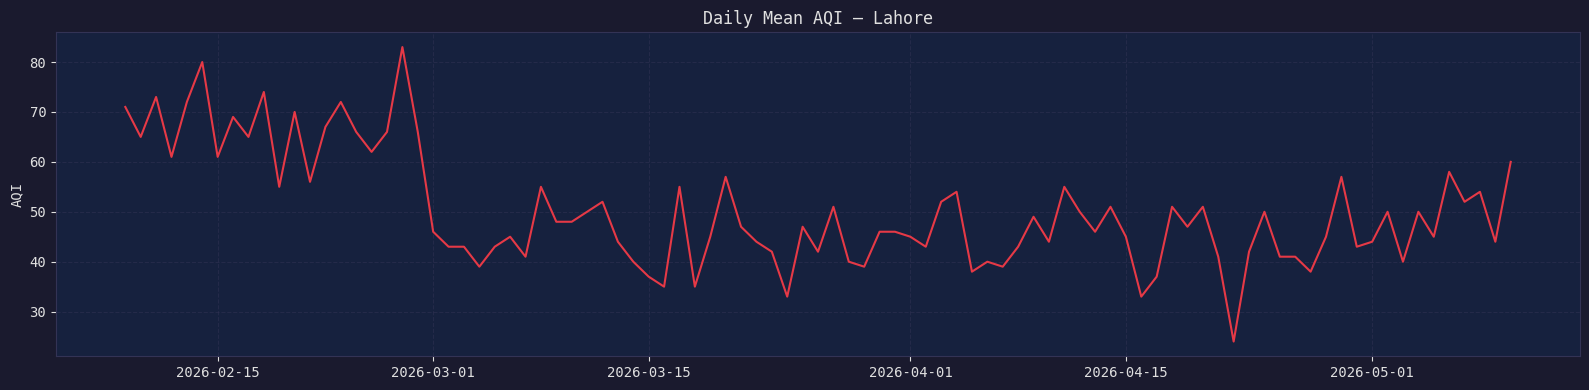

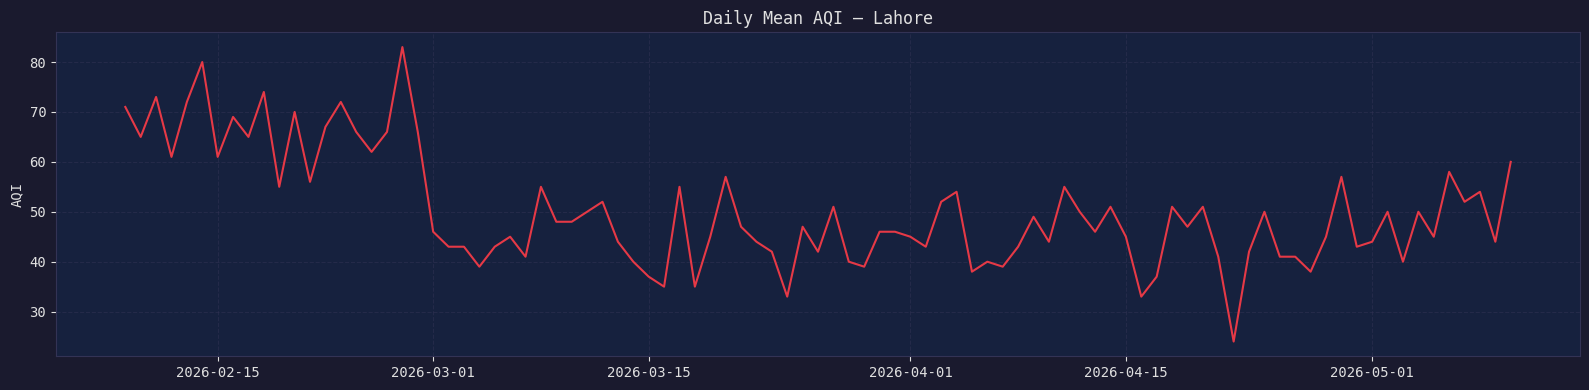

In [77]:
fig, ax = plt.subplots(figsize=(16, 4))
daily = df.set_index("timestamp")["aqi"].resample("D").mean()
ax.plot(daily.index, daily.values, color="#E63946", linewidth=1.5)
ax.set_title("Daily Mean AQI — Lahore")
ax.set_ylabel("AQI")
ax.grid(True)
plt.tight_layout()
plt.show()

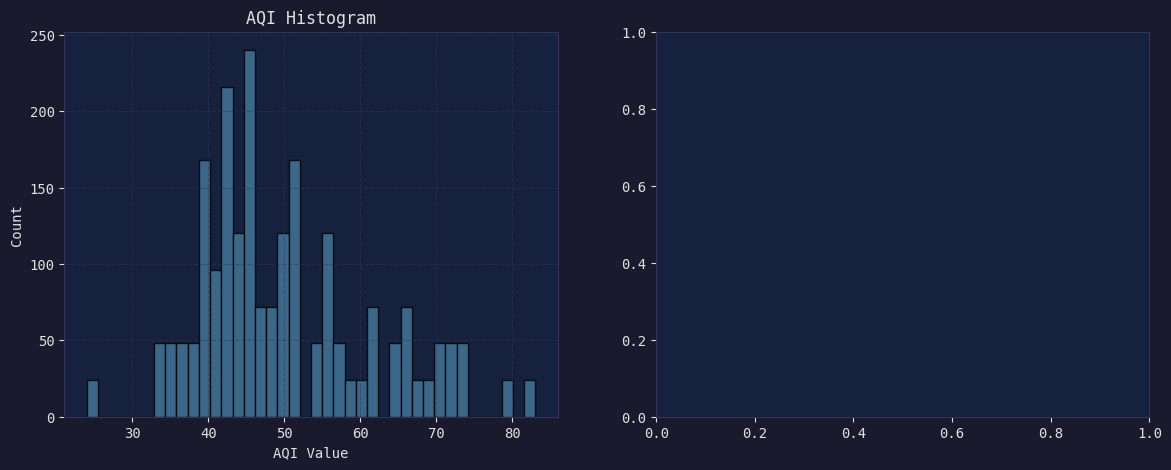

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df["aqi"].dropna(), bins=40, color="#457B9D", edgecolor="#000", alpha=0.8)
axes[0].set_title("AQI Histogram")
axes[0].set_xlabel("AQI Value")
axes[0].set_ylabel("Count")
axes[0].grid(True)

aqi_cat_label
Good        1320
Moderate     864
Name: count, dtype: int64


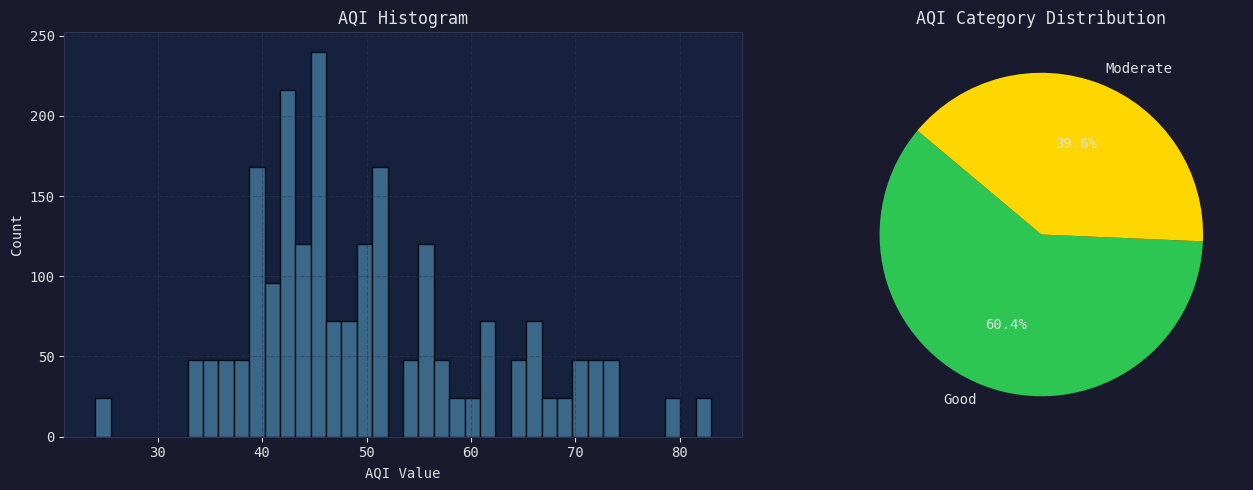

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df["aqi"].dropna(), bins=40, color="#457B9D", edgecolor="#000", alpha=0.8)
axes[0].set_title("AQI Histogram")
axes[0].set_xlabel("AQI Value")
axes[0].set_ylabel("Count")
axes[0].grid(True)

# Category pie
cat_counts = df["aqi_cat_label"].value_counts()
print(cat_counts)  # check if data exists

axes[1].pie(cat_counts.values,
            labels=cat_counts.index,
            autopct="%1.1f%%",
            startangle=140,
            colors=["#2DC653","#FFD700","#FF6B35","#E63946","#C1121F","#6D2B2B"])
axes[1].set_title("AQI Category Distribution")

plt.tight_layout()
plt.show()

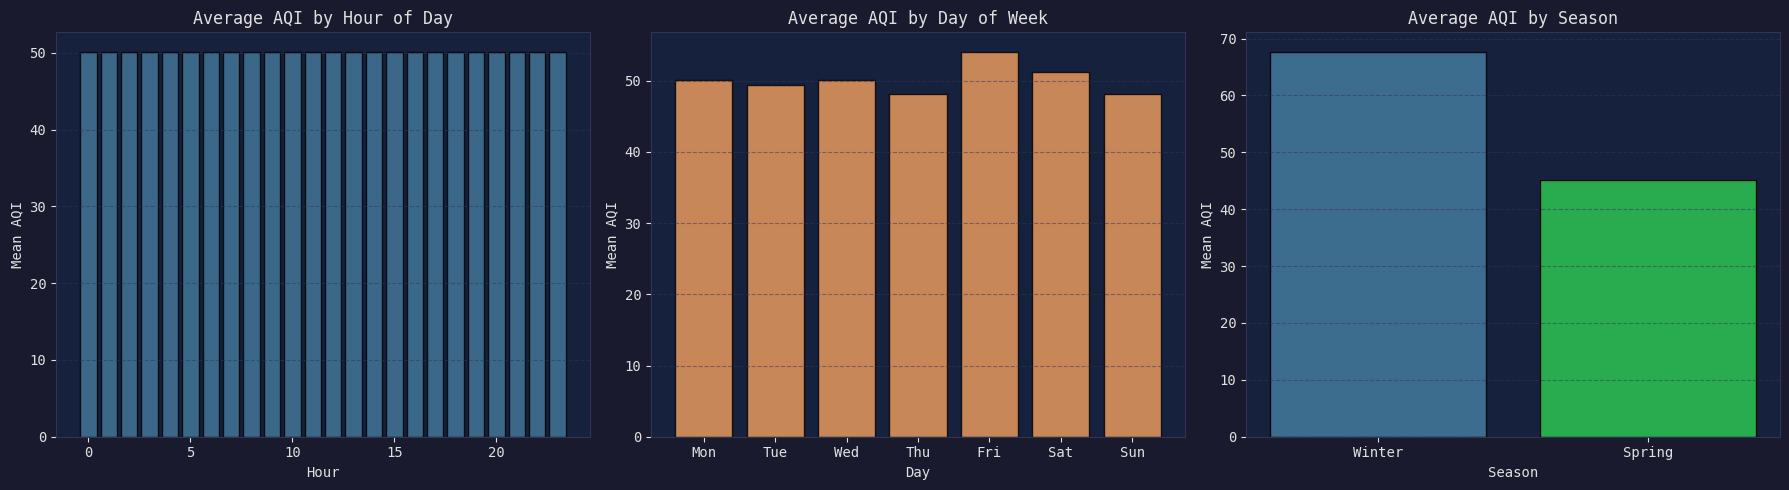

In [82]:

# ── Plot 3: Hourly & Seasonal Patterns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# By hour
hourly = df.groupby("hour")["aqi"].mean()
axes[0].bar(hourly.index, hourly.values, color="#457B9D", alpha=0.8, edgecolor="#000")
axes[0].set_title("Average AQI by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Mean AQI")
axes[0].grid(True, axis="y")

# By day of week
days = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
daily = df.groupby("day_of_week")["aqi"].mean()
axes[1].bar(daily.index, daily.values, color="#F4A261", alpha=0.8, edgecolor="#000")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(days)
axes[1].set_title("Average AQI by Day of Week")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Mean AQI")
axes[1].grid(True, axis="y")

# By season
seasons = {0:"Winter", 1:"Spring", 2:"Summer", 3:"Autumn"}
seasonal = df.groupby("season")["aqi"].mean()
axes[2].bar(
    [seasons.get(i, str(i)) for i in seasonal.index],
    seasonal.values,
    color=["#457B9D","#2DC653","#F4A261","#E63946"],
    alpha=0.85, edgecolor="#000"
)
axes[2].set_title("Average AQI by Season")
axes[2].set_xlabel("Season")
axes[2].set_ylabel("Mean AQI")
axes[2].grid(True, axis="y")

plt.tight_layout()
plt.show()

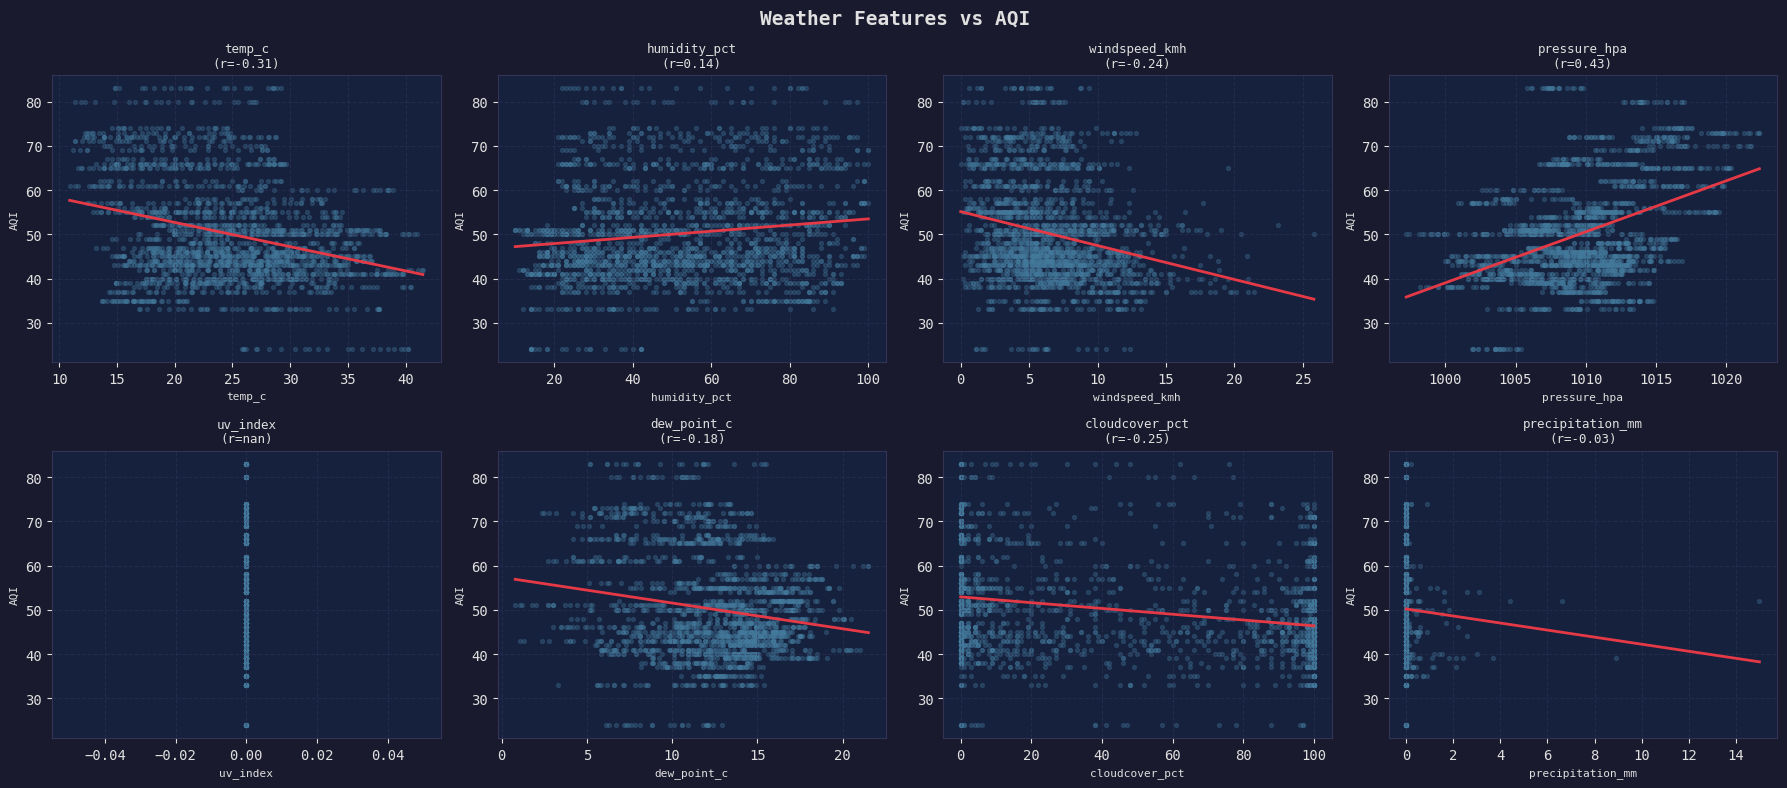

In [83]:
 #── Plot 4: Weather vs AQI Correlations ────────
weather_cols = ["temp_c", "humidity_pct", "windspeed_kmh",
                "pressure_hpa", "uv_index", "dew_point_c",
                "cloudcover_pct", "precipitation_mm"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
fig.suptitle("Weather Features vs AQI", fontsize=14, fontweight="bold")

for i, col in enumerate(weather_cols):
    x = df[col].dropna()
    y = df.loc[x.index, "aqi"].dropna()
    idx = x.index.intersection(y.index)
    axes[i].scatter(x[idx], y[idx], alpha=0.3, s=8, color="#457B9D")
    
    # Trend line
    try:
        z = np.polyfit(x[idx], y[idx], 1)
        p = np.poly1d(z)
        xline = np.linspace(x[idx].min(), x[idx].max(), 100)
        axes[i].plot(xline, p(xline), color="#E63946", linewidth=2)
    except Exception:
        pass
    
    corr = df[[col, "aqi"]].corr().iloc[0, 1]
    axes[i].set_title(f"{col}\n(r={corr:.2f})", fontsize=9)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel("AQI", fontsize=8)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

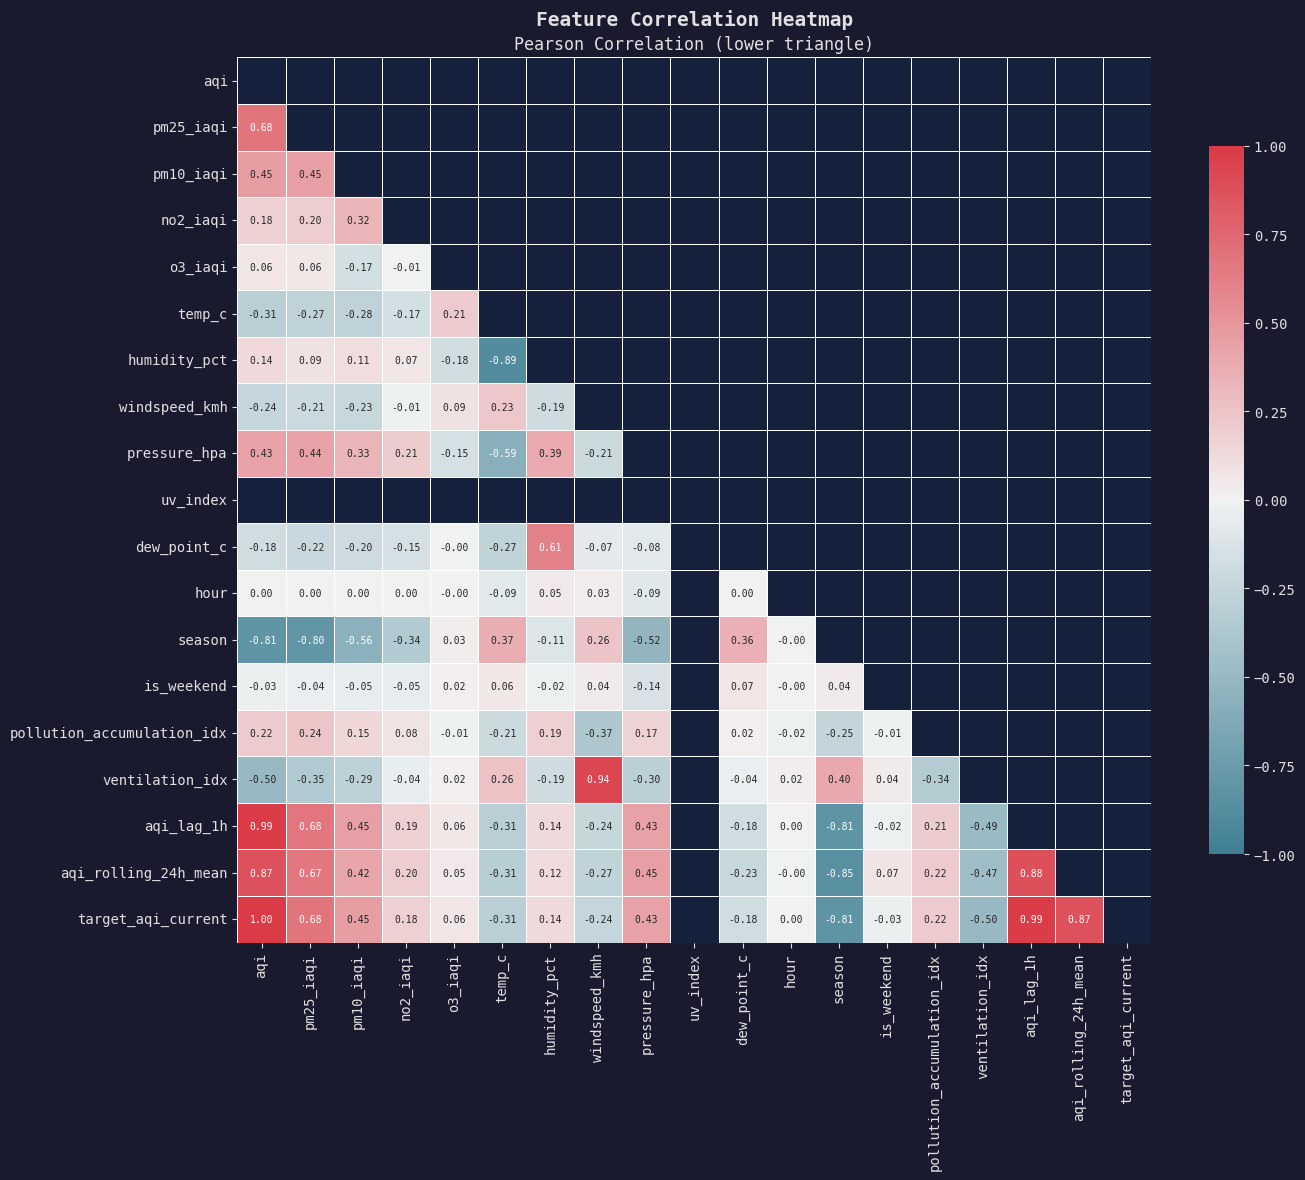

In [84]:
# ── Plot 5: Correlation Heatmap ────────
import seaborn as sns

key_cols = [
    "aqi", "pm25_iaqi", "pm10_iaqi", "no2_iaqi", "o3_iaqi",
    "temp_c", "humidity_pct", "windspeed_kmh", "pressure_hpa",
    "uv_index", "dew_point_c", "hour", "season", "is_weekend",
    "pollution_accumulation_idx", "ventilation_idx",
    "aqi_lag_1h", "aqi_rolling_24h_mean", "target_aqi_current"
]
available = [c for c in key_cols if c in df.columns]
corr = df[available].corr()

fig, ax = plt.subplots(figsize=(14, 12))
fig.suptitle("Feature Correlation Heatmap", fontsize=14, fontweight="bold")

mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            annot=True, fmt=".2f", linewidths=0.5,
            annot_kws={"size": 7}, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Pearson Correlation (lower triangle)")

plt.tight_layout()
plt.show()

Features with missing values: 18
temp_range_c            100.000000
temp_variance           100.000000
wind_variance           100.000000
wind_chill_c            100.000000
visibility_m            100.000000
heat_index_c             65.018315
aqi_rolling_24h_mean      1.098901
aqi_rolling_24h_max       1.098901
aqi_lag_24h               1.098901
aqi_change_rate_24h       1.098901
aqi_rolling_6h_mean       0.274725
aqi_lag_6h                0.274725
aqi_change_rate_6h        0.274725
aqi_rolling_3h_std        0.137363
aqi_rolling_3h_mean       0.137363
aqi_lag_3h                0.137363
aqi_change_rate_1h        0.091575
aqi_lag_1h                0.045788
dtype: float64


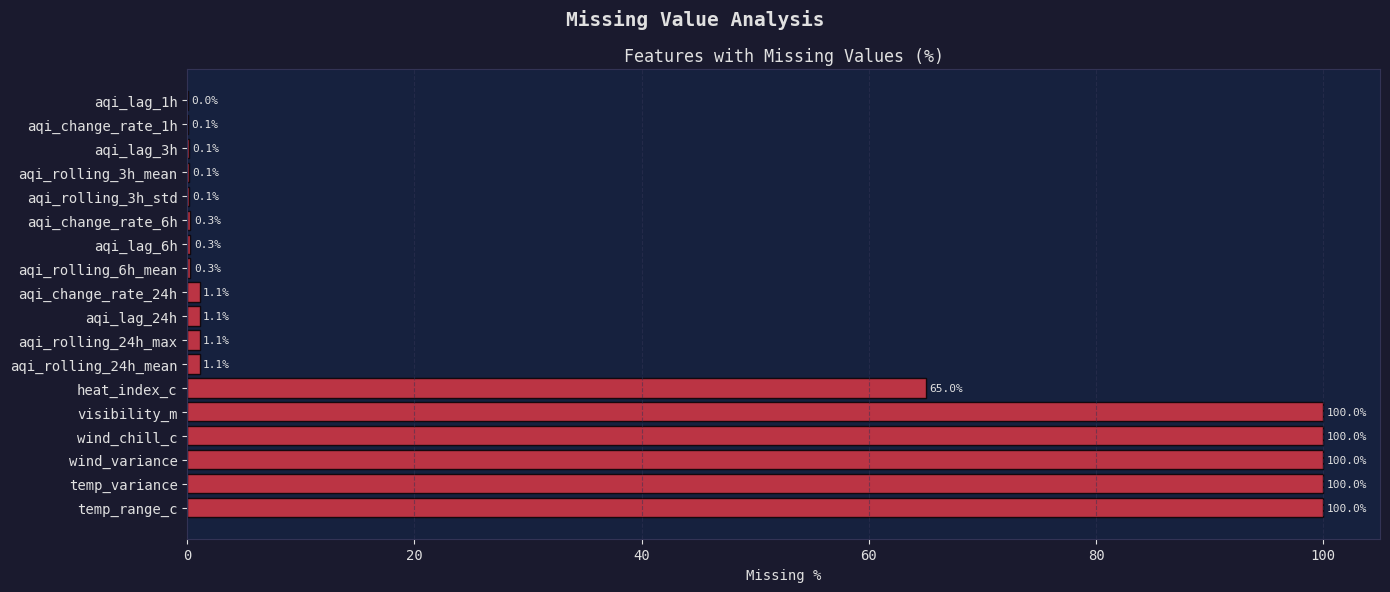

In [85]:
#missing values
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

print(f"Features with missing values: {len(missing)}")
print(missing)

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle("Missing Value Analysis", fontsize=14, fontweight="bold")

bars = ax.barh(missing.index, missing.values, color="#E63946", alpha=0.8, edgecolor="#000")
ax.set_xlabel("Missing %")
ax.set_title("Features with Missing Values (%)")
ax.grid(True, axis="x")

for bar, val in zip(bars, missing.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()

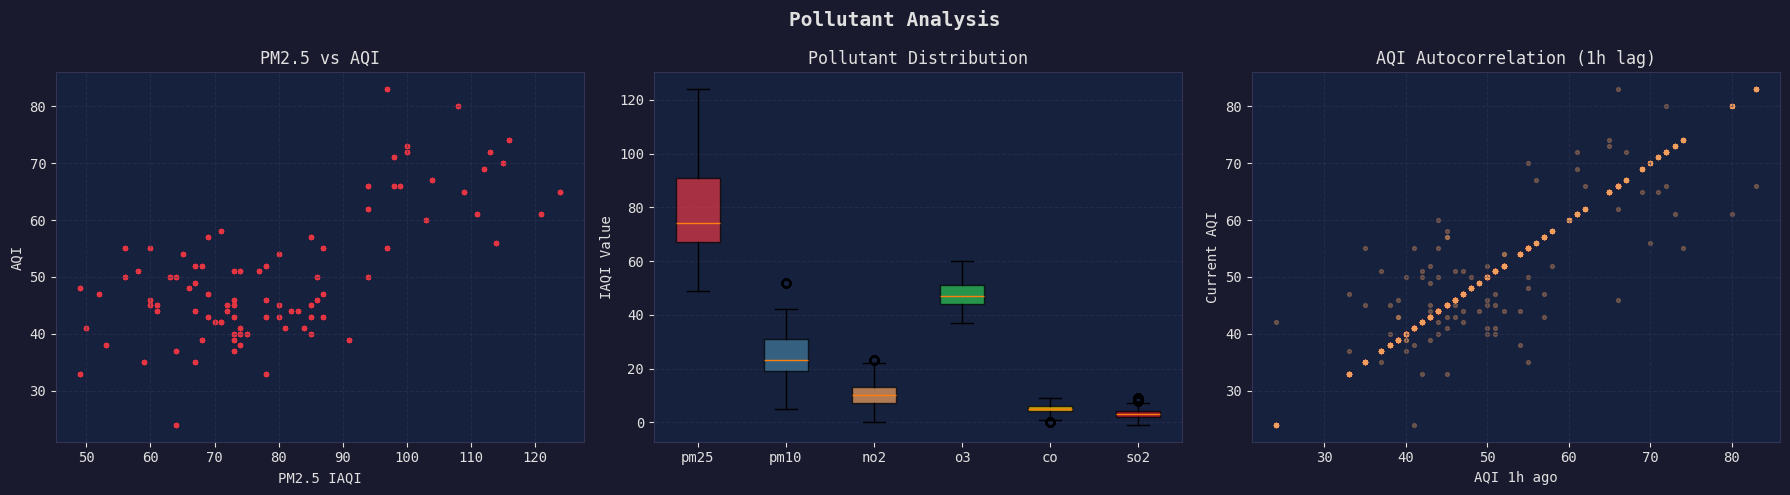

In [86]:
# Pollutant Analysis:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Pollutant Analysis", fontsize=14, fontweight="bold")

# PM2.5 vs AQI
axes[0].scatter(df["pm25_iaqi"], df["aqi"], alpha=0.3, s=8, color="#E63946")
axes[0].set_xlabel("PM2.5 IAQI")
axes[0].set_ylabel("AQI")
axes[0].set_title("PM2.5 vs AQI")
axes[0].grid(True)

# Pollutant box plots
poll_cols = ["pm25_iaqi","pm10_iaqi","no2_iaqi","o3_iaqi","co_iaqi","so2_iaqi"]
available = [c for c in poll_cols if c in df.columns]
data_to_plot = [df[c].dropna().values for c in available]
bp = axes[1].boxplot(data_to_plot, patch_artist=True,
                     labels=[c.replace("_iaqi","") for c in available])
colors = ["#E63946","#457B9D","#F4A261","#2DC653","#FFD700","#C1121F"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title("Pollutant Distribution")
axes[1].set_ylabel("IAQI Value")
axes[1].grid(True, axis="y")

# AQI autocorrelation
axes[2].scatter(df["aqi_lag_1h"], df["aqi"], alpha=0.3, s=8, color="#F4A261")
axes[2].set_xlabel("AQI 1h ago")
axes[2].set_ylabel("Current AQI")
axes[2].set_title("AQI Autocorrelation (1h lag)")
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [87]:
# ── Plot 7: PM2.5 vs AQI ──────────────────────────────────────────────────
def plot_pollutant_analysis(df: pd.DataFrame):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Pollutant Analysis", fontsize=14,
                 color=COLORS["primary"], fontweight="bold")

Text(0, 0.5, 'IAQI Value')

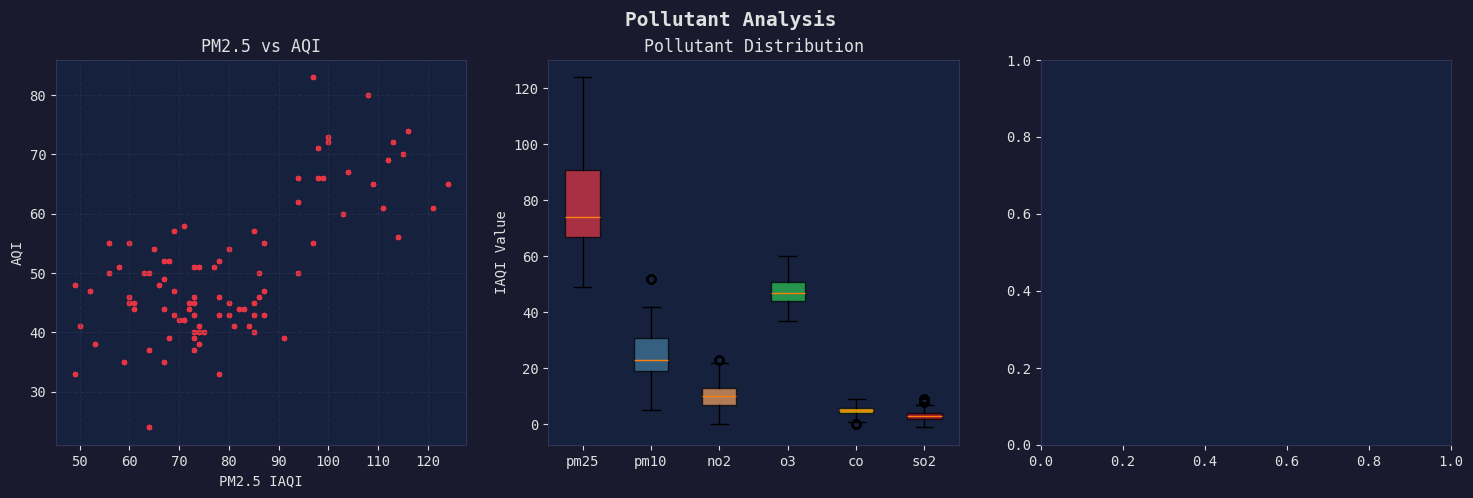

In [88]:
# PM2.5 vs AQI
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Pollutant Analysis", fontsize=14, fontweight="bold")

# PM2.5 vs AQI
if "pm25_iaqi" in df.columns:
    axes[0].scatter(df["pm25_iaqi"], df["aqi"],
                    alpha=0.3, s=8, color="#E63946")
    axes[0].set_xlabel("PM2.5 IAQI")
    axes[0].set_ylabel("AQI")
    axes[0].set_title("PM2.5 vs AQI")
    axes[0].grid(True)

# Pollutant box plots
poll_cols = ["pm25_iaqi","pm10_iaqi","no2_iaqi","o3_iaqi","co_iaqi","so2_iaqi"]
available = [c for c in poll_cols if c in df.columns]
data_to_plot = [df[c].dropna().values for c in available]
bp = axes[1].boxplot(data_to_plot, patch_artist=True,
                     labels=[c.replace("_iaqi","") for c in available])
colors = ["#E63946","#457B9D","#F4A261","#2DC653","#FFD700","#C1121F"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title("Pollutant Distribution")
axes[1].set_ylabel("IAQI Value")

In [89]:
print(df["aqi_lag_1h"].value_counts().head())
print(df["aqi_lag_1h"].isna().sum())

aqi_lag_1h
45.0    144
43.0    144
44.0    120
50.0    120
41.0     96
Name: count, dtype: int64
1


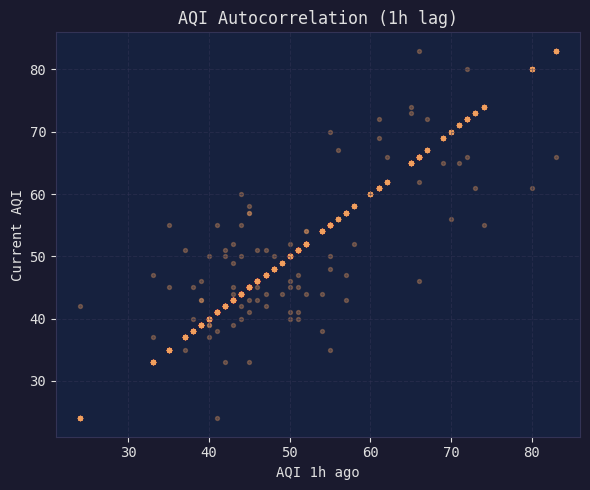

In [90]:
# AQI lag correlation - fixed
lag_df = df[["aqi_lag_1h", "aqi"]].dropna()

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(lag_df["aqi_lag_1h"], lag_df["aqi"],
           alpha=0.3, s=8, color="#F4A261")
ax.set_xlabel("AQI 1h ago")
ax.set_ylabel("Current AQI")
ax.set_title("AQI Autocorrelation (1h lag)")
ax.grid(True)
plt.tight_layout()
plt.show()



In [91]:
print("\n" + "="*60)
print("  EDA SUMMARY — AQI Feature Dataset")
print("="*60)
print(f"  Total rows       : {len(df)}")
print(f"  Total features   : {len(df.columns)}")

if "timestamp" in df.columns:
    print(f"  Date range       : {df['timestamp'].min()} → {df['timestamp'].max()}")

if "aqi" in df.columns:
    print(f"  AQI mean         : {df['aqi'].mean():.1f}")
    print(f"  AQI median       : {df['aqi'].median():.1f}")
    print(f"  AQI min/max      : {df['aqi'].min():.0f} / {df['aqi'].max():.0f}")
    print(f"  AQI std          : {df['aqi'].std():.1f}")

if "aqi_cat_label" in df.columns:
    print(f"\n  AQI Category Distribution:")
    for cat, cnt in df["aqi_cat_label"].value_counts().items():
        pct = cnt/len(df)*100
        print(f"    {cat:35s}: {cnt:5d} ({pct:.1f}%)")

missing = df.isnull().sum()
missing = missing[missing > 0]
print(f"\n  Features with missing values: {len(missing)}")
for col, cnt in missing.head(5).items():
    print(f"    {col:35s}: {cnt} ({cnt/len(df)*100:.1f}%)")

print("="*60)


  EDA SUMMARY — AQI Feature Dataset
  Total rows       : 2184
  Total features   : 68
  Date range       : 2026-02-09 00:00:00+00:00 → 2026-05-10 23:00:00+00:00
  AQI mean         : 50.2
  AQI median       : 47.0
  AQI min/max      : 24 / 83
  AQI std          : 11.5

  AQI Category Distribution:
    Good                               :  1320 (60.4%)
    Moderate                           :   864 (39.6%)

  Features with missing values: 18
    visibility_m                       : 2184 (100.0%)
    heat_index_c                       : 1420 (65.0%)
    wind_chill_c                       : 2184 (100.0%)
    temp_range_c                       : 2184 (100.0%)
    temp_variance                      : 2184 (100.0%)
